# Credit Risk Model — Probability of Default (PD) Estimation

**Objective.** Estimate the probability that a loan applicant will default (`loan_status = 1`) and turn that probability into an approve/decline decision that a lender could actually use.

**Data.** Credit Risk Dataset (Kaggle, `laotse/credit-risk-dataset`): 32,581 loan applications, 11 predictor columns plus the target.

**How the model is judged.**
- **Ranking quality:** ROC-AUC and its banking equivalent, the Gini coefficient (Gini = 2·AUC − 1), plus the KS statistic.
- **Probability quality (calibration):** a PD model must produce probabilities that match observed default rates, because pricing and expected loss are computed from them. Measured with the Brier score and a calibration curve.
- **Decision quality:** the approval threshold is chosen from an explicit business trade-off (money lost on a default vs. interest earned on a good loan), not left at the default 0.5.

**Two separate layers.** The work distinguishes the **predictive model**, which estimates each applicant's PD, from the **decision policy**, which turns PDs into approvals. The model is judged on statistical grounds (ranking and calibration). The policy depends on economic assumptions (loss given default, loan term, effective rate, funding cost, recoveries, risk appetite); if those change, the policy is recalculated while the model stays the same.

**Methodological rules followed throughout.**
1. Only rule-based fixes of data errors happen before the train/test split. Anything that learns a number from the data (medians, encoders, scalers, model parameters) is fitted on training data only, inside an sklearn `Pipeline`.
2. Exploratory analysis that looks at the target is done on the training set only, so the test set stays unseen until the final evaluation.
3. Model selection, hyperparameters and the decision threshold are chosen with 5-fold cross-validation on the training set. The test set is used exactly once, at the end.

**Known limitations.** Educational dataset with no application dates, so out-of-time validation and population-stability checks are not possible. No information on loan term, fees or recoveries, so the business simulation relies on stated assumptions.

## Executive Summary

| | Logistic Regression | XGBoost |
|---|---|---|
| ROC-AUC, 5-fold CV on train | 0.870 ± 0.005 | 0.947 ± 0.002 |
| ROC-AUC, test | 0.870 | 0.953 |
| Gini / KS, test | 0.74 / 0.59 | 0.91 / 0.78 |
| Brier score, test (no-skill model: 0.171) | 0.107 | 0.049 |
| CV ROC-AUC without the lender's grade and rate | 0.817 | 0.903 |
| Profit-optimal threshold | 0.18 | 0.18 |
| Defaulters caught / precision of declines | 83% / 48% | 86% / 72% |
| Simulated test profit (approving everyone: −4.32M) | +2.13M | +3.34M |

**Key findings**

- **XGBoost is the recommended model.** It ranks applicants better, its probabilities are well calibrated, and at the chosen threshold it declines far fewer good customers than Logistic Regression (478 vs 1,271) while also approving fewer defaulters (199 vs 242).
- **Where its advantage comes from:** default risk jumps sharply once a loan exceeds about 30% of the applicant's income (Section 12.4). A single straight line, which is what Logistic Regression fits, cannot represent that step.
- **The threshold matters as much as the model.** With the usual 0.5 cut-off XGBoost catches 75% of defaulters; the profit-based threshold of 0.18 raises that to 86%.
- **Part of the performance comes from the lender's own assessment.** `loan_grade` and `loan_int_rate` are assigned by the lender, and the grade already includes credit-bureau information. Without them, CV AUC falls to 0.817 (Logistic Regression) and 0.903 (XGBoost). The full models therefore apply after grading and pricing; a reduced XGBoost is a credible pre-approval model.
- **Limitations:** the business simulation rests on stated assumptions (60% loss given default, one year of interest as gain), and the dataset has no dates, so performance over time cannot be validated.

## 1. Setup and Data Loading

In [ ]:
!pip -q install kagglehub xgboost shap

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42

In [3]:
import kagglehub

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df_raw = pd.read_csv(os.path.join(path, "credit_risk_dataset.csv"))

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 32,581 rows x 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 1.1 Data Dictionary

| Column | Type | Description |
|---|---|---|
| `person_age` | int | Applicant's age (years) |
| `person_income` | int | Annual income (currency unspecified) |
| `person_home_ownership` | categorical | RENT, OWN, MORTGAGE, OTHER |
| `person_emp_length` | float | Employment length (years) |
| `loan_intent` | categorical | PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION |
| `loan_grade` | categorical | Lender's risk grade, A (lowest risk) to G (highest risk) |
| `loan_amnt` | int | Amount requested |
| `loan_int_rate` | float | Interest rate (%) |
| `loan_percent_income` | float | Loan amount / annual income |
| `cb_person_default_on_file` | Y/N | Previous default recorded by the credit bureau |
| `cb_person_cred_hist_length` | int | Length of credit history (years) |
| **`loan_status`** | int | **Target:** 1 = default, 0 = repaid |

## 2. Data Quality Audit — Single Columns

Before changing anything, we look at each column on its own: value ranges (with extreme percentiles, where errors usually hide), category counts, missing values and duplicates. This section only **describes**; no rows are modified.

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
                "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
df_raw[numeric_cols].describe(percentiles=[.01, .5, .99, .999]).T

,count,mean,std,min,1%,50%,99%,99.9%,max
person_age,32581.0,27.734600,6.348078,20.00,21.00,26.00,50.00,66.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,14400.00,55000.00,225200.00,648000.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,0.00,4.00,18.00,25.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,1000.00,8000.00,29800.00,35000.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,5.42,10.99,18.62,20.89,23.22
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.02,0.15,0.50,0.63,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,2.00,4.00,17.00,29.00,30.00


In [6]:
for col in ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]:
    print(df_raw[col].value_counts().to_string(), "\n")

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107 

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605 

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64 

cb_person_default_on_file
N    26836
Y     5745 



In [7]:
print("Target distribution:")
print(df_raw["loan_status"].value_counts(normalize=True).round(4).to_string())
print("\nFully duplicated rows:", df_raw.duplicated().sum())
print("Missing values:")
print(df_raw.isna().sum()[lambda s: s > 0].to_string())

Target distribution:
loan_status
0    0.7818
1    0.2182

Fully duplicated rows: 165
Missing values:
person_emp_length     895
loan_int_rate        3116


In [8]:
print("person_age > 100:        ", (df_raw["person_age"] > 100).sum())
print("person_emp_length > 60:  ", (df_raw["person_emp_length"] > 60).sum())
print("person_income > 1,000,000:", (df_raw["person_income"] > 1_000_000).sum())

person_age > 100:         5
person_emp_length > 60:   2
person_income > 1,000,000: 9


**What the audit shows**

- The target is **imbalanced**: about 22% defaults, 78% repaid. A model that always predicts "repaid" would already be 78% accurate, which is why accuracy is not used to judge the models.
- **165 rows are exact duplicates** of other rows.
- `person_age` jumps from 66 (99.9th percentile) to a maximum of 144, and `person_emp_length` has two rows at exactly 123 years. These look like entry errors.
- `person_income` has a long right tail (maximum 6,000,000). High incomes are not impossible, so this needs a closer look before deciding.
- `person_emp_length` and `loan_int_rate` have missing values (895 and 3,116). How to fill them is decided later, after the split.
- `OTHER` (home ownership) and grade `G` are rare categories: not errors, but they matter for encoding.

## 3. Data Quality Audit — Consistency Between Columns

A value can look normal on its own and still be impossible when compared with another column. Each check below uses a real-world rule rather than an arbitrary cutoff.

In [9]:
# Rule 1: nobody can have worked more years than (age - 14).
mask_emp = df_raw["person_emp_length"] > (df_raw["person_age"] - 14)
print("Employment longer than age allows:", mask_emp.sum())
df_raw.loc[mask_emp, ["person_age", "person_emp_length", "person_income", "loan_status"]]

Employment longer than age allows: 2


,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


In [10]:
# Rule 2: credit history should not be longer than (age - 18).
mask_hist = df_raw["cb_person_cred_hist_length"] > (df_raw["person_age"] - 18)
excess = df_raw.loc[mask_hist, "cb_person_cred_hist_length"] - (df_raw.loc[mask_hist, "person_age"] - 18)
print("Rows breaking the rule:", mask_hist.sum())
print("By how many years:")
print(excess.value_counts().sort_index().to_string())

Rows breaking the rule: 781
By how many years:
1    776
2      5


In [11]:
# Rule 3: loan_percent_income should equal loan_amnt / person_income (stored with 2 decimals).
diff = (df_raw["loan_percent_income"] - df_raw["loan_amnt"] / df_raw["person_income"]).abs()
print("Consistent within rounding (diff <= 0.005):", (diff <= 0.005).sum())
print("Clearly inconsistent (diff > 0.05):        ", (diff > 0.05).sum())

Consistent within rounding (diff <= 0.005): 31666
Clearly inconsistent (diff > 0.05):         68


**What the checks show**

- The two rows with 123 years of employment belong to applicants aged 21 and 22: **provably impossible**.
- Credit history exceeds (age − 18) in 781 rows, but almost always by exactly one year. That pattern points to a measurement convention (for example, a credit history starting at 17), not to errors. The rule was too strict, so these rows are **kept**.
- `loan_percent_income` is a derived field (amount ÷ income), and 68 rows disagree with their own source columns by more than 5 percentage points.

## 4. Fixing Data Errors (Rule-Based, Before the Split)

Only fixes that follow a fixed rule applied row by row are done here. None of them learns a statistic from the data, so none can leak information from the test set. Anything that needs a statistic (for example, a median to fill missing values) waits until after the split.

In [12]:
# Decision 1 — remove exact duplicates.
# No legitimate reason exists for two byte-identical applications. Removing them
# BEFORE the split also prevents the same row from landing in both train and test,
# which would inflate test scores.
df = df_raw.drop_duplicates().copy()
print(f"Removed {len(df_raw) - len(df)} duplicates -> {len(df):,} rows")

Removed 165 duplicates -> 32,416 rows


In [13]:
# Decision 2 — remove provably impossible rows.
# Age above 100 (5 rows, up to 144 years: not plausible for a loan applicant)
# and employment length that exceeds what the applicant's age allows (2 rows).
impossible = (df["person_age"] > 100) | (df["person_emp_length"] > df["person_age"] - 14)
print(f"Removed {impossible.sum()} impossible rows")
df = df[~impossible].copy()
print(f"{len(df):,} rows remaining")

Removed 7 impossible rows
32,409 rows remaining


In [14]:
# Decision 3 — recompute loan_percent_income from its source columns for ALL rows.
# Patching only the 68 inconsistent rows would leave the rest of unknown quality;
# the two primary fields are more trustworthy than a pre-computed column.
df["loan_percent_income"] = df["loan_amnt"] / df["person_income"]

In [15]:
# Decision 4 — look at high incomes before deciding anything.
high = df["person_income"] > 500_000
print("Rows with income > 500,000:", high.sum())
print("Max income now:", f"{df['person_income'].max():,}")
print(df.loc[high, "person_income"].describe().round(0).to_string())

Rows with income > 500,000: 51
Max income now: 2,039,784
count         51.0
mean      822935.0
std       348041.0
min       504000.0
25%       600000.0
50%       741600.0
75%       894500.0
max      2039784.0


**Decision 4 outcome.** The 6,000,000 income belonged to the 144-year-old applicant and is already gone. The remaining high incomes rise gradually up to about 2 million, without the abrupt jump that identified the age errors, so they are **kept**. Their strong skew is handled later with a log transformation for the linear model (Section 7).

### 4.1 Cleaning Log

| Finding | Rows | Decision | Reason |
|---|---|---|---|
| Exact duplicates | 165 | Removed | No legitimate duplicate applications; also avoids train/test overlap |
| Age > 100 | 5 | Removed | Biologically implausible |
| Employment longer than age allows | 2 | Removed | Logically impossible |
| Credit history 1–2 years too long | 781 | Kept | Consistent with a measurement convention, not an error |
| `loan_percent_income` inconsistent | 68 | Recomputed for all rows | Derived field; source columns are more reliable |
| Income > 500,000 | 51 | Kept; log-transformed for the linear model | Rare but plausible |
| Missing `person_emp_length` / `loan_int_rate` | 895 / 3,116 | Imputed inside the model pipeline | Needs statistics, so must be learned from training data only |
| Rare `OTHER` / grade `G` | 107 / 64 | Encoding decision (Section 7) | Not errors |

## 5. Data Types and Fixed Encodings

These conversions use fixed rules that do not depend on the data (Y always means 1; A always comes before B), so they are safe before the split.

In [16]:
# Previous default: Y/N -> 1/0.
df["cb_person_default_on_file"] = (df["cb_person_default_on_file"] == "Y").astype(int)

# Loan grade has a real order (A = lowest risk ... G = highest risk).
# Mapping it to 0..6 keeps that order, which one-hot encoding would throw away.
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
df["loan_grade_code"] = df["loan_grade"].map({g: i for i, g in enumerate(grade_order)})

# Nominal categories: no natural order.
for col in ["person_home_ownership", "loan_intent"]:
    df[col] = df[col].astype(str)

df = df.drop(columns=["loan_grade"])
print("Final columns:", list(df.columns))

Final columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_grade_code']


## 6. Train/Test Split

From this point on, the **test set is locked away** until the final evaluation (Section 11). It plays the role of future applicants the model has never seen.

- 80% train / 20% test.
- `stratify=y` keeps the same default rate (~22%) in both sets.
- Cross-validation on the training set (Section 9) replaces a separate validation set: every training row is used both to fit and to validate, in turns, which gives a more stable estimate than a single extra split.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape} | default rate {y_train.mean():.4f}")
print(f"Test:  {X_test.shape} | default rate {y_test.mean():.4f}")

train = X_train.assign(loan_status=y_train)   # used for EDA only

Train: (25927, 11) | default rate 0.2187
Test:  (6482, 11) | default rate 0.2188


## 7. Exploratory Data Analysis (Training Set Only)

EDA that looks at the target is done on the training set so that no decision is influenced by the test set. Each subsection ends with the modeling decision it supports.

### 7.1 Distributions and Skew

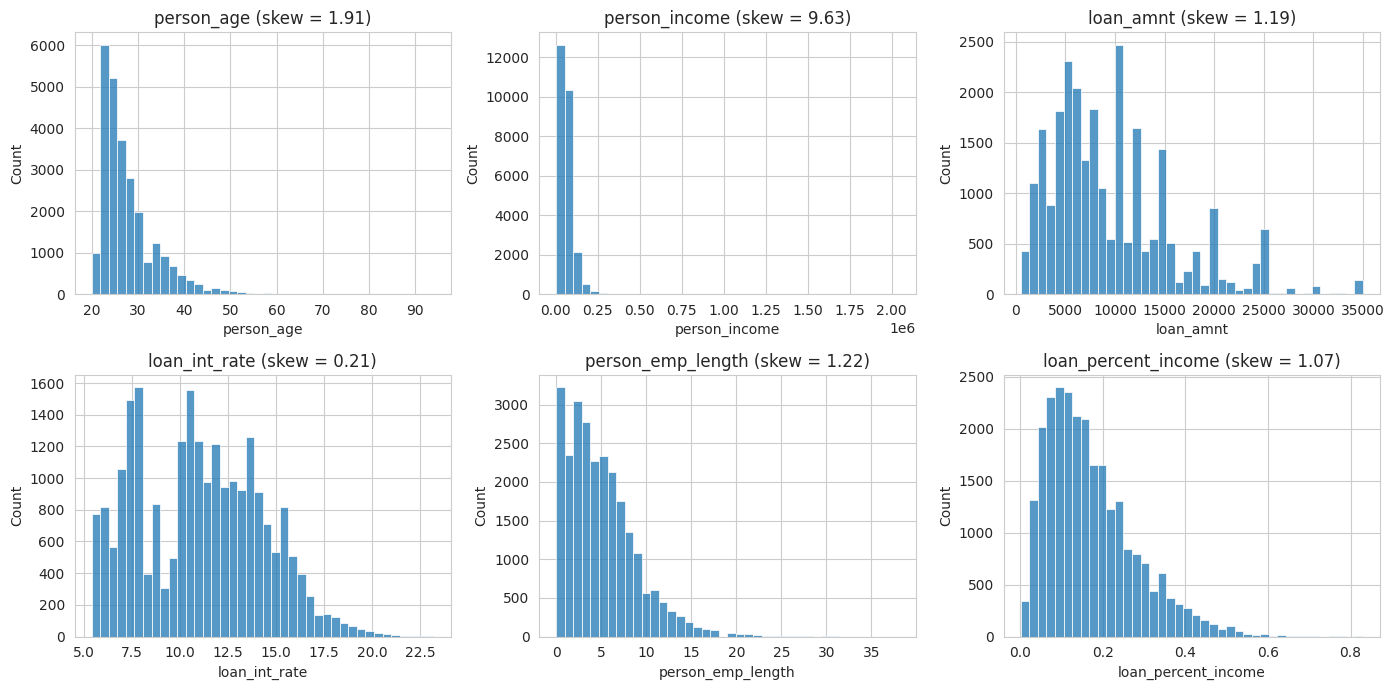

Skew of person_income: 9.63 -> after log: 0.15


In [18]:
cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate",
        "person_emp_length", "loan_percent_income"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(train[col].dropna(), bins=40, ax=ax)
    ax.set_title(f"{col} (skew = {train[col].skew():.2f})")
plt.tight_layout()
plt.show()

print(f"Skew of person_income: {train['person_income'].skew():.2f} "
      f"-> after log: {np.log1p(train['person_income']).skew():.2f}")

**Decision.** `person_income` is heavily right-skewed: a few very high incomes would dominate a linear model. Taking the logarithm compresses the tail, and it also matches how income works economically (the difference between 20k and 40k matters more than between 520k and 540k). The log is applied **only for Logistic Regression**; tree models split on value order, so a monotonic transformation changes nothing for them.

### 7.2 Correlations

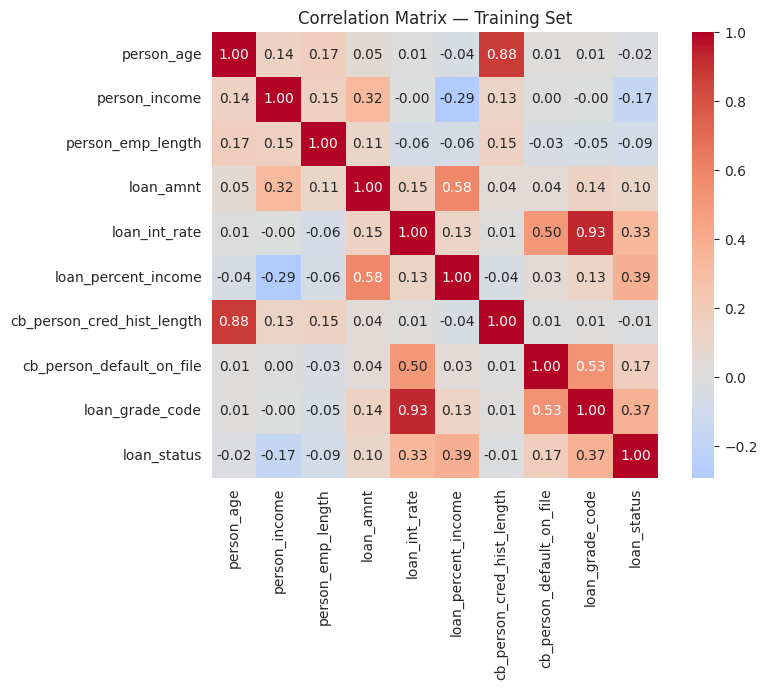

In [19]:
num = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate",
       "loan_percent_income", "cb_person_cred_hist_length", "cb_person_default_on_file",
       "loan_grade_code", "loan_status"]
plt.figure(figsize=(9, 7))
sns.heatmap(train[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Training Set")
plt.tight_layout()
plt.show()

Two pairs stand out: `person_age` with `cb_person_cred_hist_length` (older applicants have longer histories) and `loan_grade_code` with `loan_int_rate` (the lender prices loans according to their grade). Their effect on the linear model is measured with VIF in Section 8.

### 7.3 Default Rate by Category

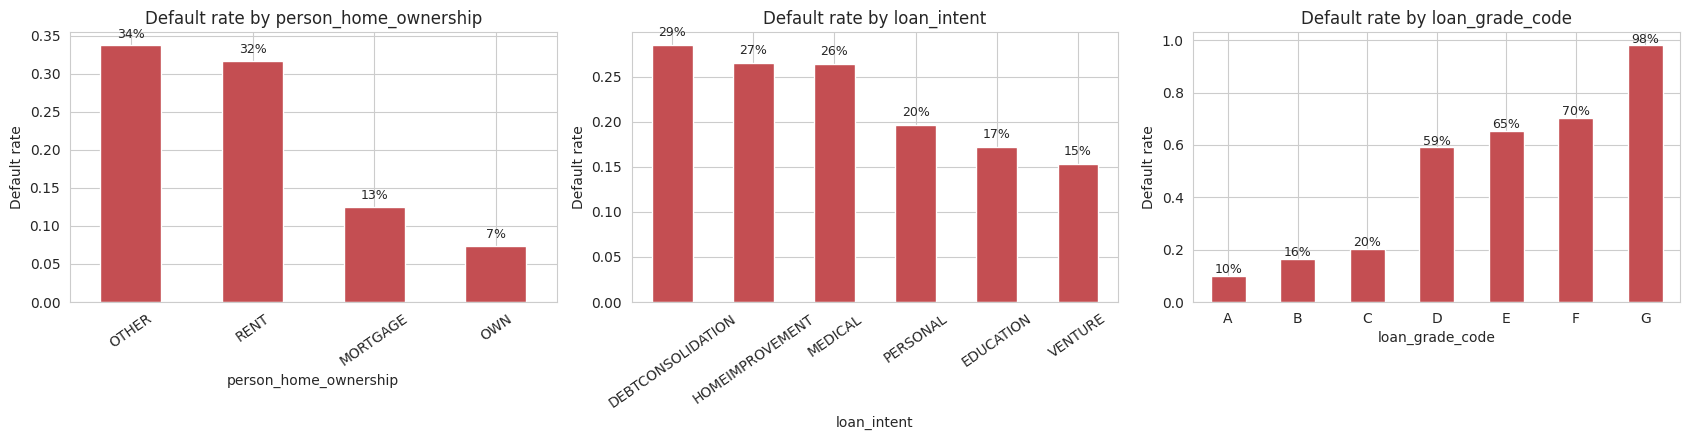

                        mean  count
person_home_ownership              
MORTGAGE               0.125  10715
OTHER                  0.337     83
OWN                    0.074   2030
RENT                   0.317  13099


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["person_home_ownership", "loan_intent", "loan_grade_code"]):
    rates = train.groupby(col)["loan_status"].mean()
    if col != "loan_grade_code":
        rates = rates.sort_values(ascending=False)
    rates.plot.bar(ax=ax, color="#C44E52")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=35)
    for i, v in enumerate(rates):
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=9)
axes[2].set_xticklabels(grade_order, rotation=0)
plt.tight_layout()
plt.show()

print(train.groupby("person_home_ownership")["loan_status"].agg(["mean", "count"]).round(3).to_string())

**Reading the home-ownership chart.** Renters default far more than applicants who own a home, whether fully paid (`OWN`) or still under mortgage (`MORTGAGE`); outright owners default least. This is the pattern the model coefficients will be compared against in Section 12.

The default rate never decreases from grade A to G, which supports the ordinal 0–6 encoding of `loan_grade`. The increase is not even, though: there is a sharp jump between C and D (about 20% to 59%), and grade G defaults almost always. Trees can capture that jump directly; the linear model can only approximate it with one slope.

### 7.4 Interest Rate and Debt Burden by Outcome

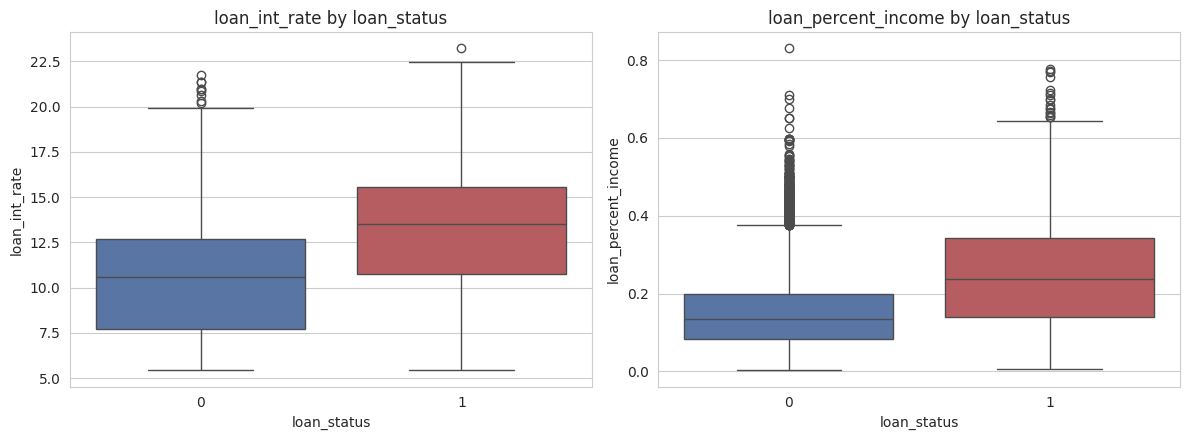

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["loan_int_rate", "loan_percent_income"]):
    sns.boxplot(data=train, x="loan_status", y=col, hue="loan_status", legend=False,
                palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax)
    ax.set_title(f"{col} by loan_status")
plt.tight_layout()
plt.show()

Defaulters pay clearly higher interest rates and borrow a larger share of their income. Both variables are expected to be among the strongest predictors.

### 7.5 Previous Default and Loan Grade

In [22]:
print("Default rate by previous default on file:")
print(train.groupby("cb_person_default_on_file")["loan_status"].mean().round(3).to_string())

print("\nShare of applicants with a previous default, by grade:")
ct = pd.crosstab(train["loan_grade_code"], train["cb_person_default_on_file"], normalize="index")
ct.index = grade_order
print(ct.round(3).to_string())

Default rate by previous default on file:
cb_person_default_on_file
0    0.186
1    0.370

Share of applicants with a previous default, by grade:
cb_person_default_on_file      0      1
A                          1.000  0.000
B                          1.000  0.000
C                          0.491  0.509
D                          0.484  0.516
E                          0.526  0.474
F                          0.541  0.459
G                          0.444  0.556


Applicants with a previous default are about twice as likely to default again.

The crosstab reveals something about **how the lender assigns grades**: no applicant with a previous default ever receives grade A or B. The grade is therefore partly built from credit-bureau information. This explains why `loan_grade_code`, `loan_int_rate` and `cb_person_default_on_file` overlap, and why their individual coefficients in a linear model should be read with care.

### 7.6 Missing Values: Is "Missing" Itself Informative?

Before filling a missing value, we check whether the fact that it is missing says something about risk. If it does, filling it silently would erase a signal.

In [23]:
for col in ["person_emp_length", "loan_int_rate"]:
    miss = train[col].isna()
    print(f"{col}: {miss.sum()} missing in train")
    print(f"  default rate when missing: {train.loc[miss, 'loan_status'].mean():.3f}")
    print(f"  default rate when present: {train.loc[~miss, 'loan_status'].mean():.3f}")

print("\nMedian loan_int_rate by grade (train):")
med = train.groupby("loan_grade_code")["loan_int_rate"].median()
med.index = grade_order
print(med.round(2).to_string())
print(f"Global median: {train['loan_int_rate'].median():.2f}")

person_emp_length: 710 missing in train
  default rate when missing: 0.330
  default rate when present: 0.216
loan_int_rate: 2463 missing in train
  default rate when missing: 0.207
  default rate when present: 0.220

Median loan_int_rate by grade (train):
A     7.49
B    10.99
C    13.49
D    15.31
E    16.77
F    18.53
G    20.16
Global median: 10.99


**Decisions.**
- **`person_emp_length`:** applicants with missing employment length default noticeably more often. The value is filled with the training median, and a separate 0/1 column `missingindicator_person_emp_length` records that it was missing, so the signal is kept.
- **`loan_int_rate`:** missingness barely changes the default rate, so no indicator is added. But the rate depends strongly on the grade (see the medians), so a single global median would give grade-A loans too high a rate and grade-G loans too low a rate. Missing rates are filled with the **median of the same grade**, learned from training data.

### 7.7 Rare Category `OTHER`

In [24]:
sub = train[train["person_home_ownership"].isin(["OTHER", "RENT"])]
table = pd.crosstab(sub["person_home_ownership"], sub["loan_status"])
chi2, p_value, _, _ = stats.chi2_contingency(table)
print(table.to_string())
print(f"\nDefault rate OTHER: {table.loc['OTHER', 1] / table.loc['OTHER'].sum():.3f} | "
      f"RENT: {table.loc['RENT', 1] / table.loc['RENT'].sum():.3f}")
print(f"Chi-square test OTHER vs RENT: p-value = {p_value:.3f}")

loan_status               0     1
person_home_ownership            
OTHER                    55    28
RENT                   8951  4148

Default rate OTHER: 0.337 | RENT: 0.317
Chi-square test OTHER vs RENT: p-value = 0.775


**Decision.** `OTHER` has very few training rows and a default rate that is not statistically different from `RENT` (the chi-square p-value is well above 0.05). A dummy column built on so few rows would be unstable, so `OTHER` is merged into `RENT`.

## 8. Preprocessing Pipelines

All transformations that learn something from the data are wrapped in an sklearn `Pipeline`. A pipeline guarantees that, whenever the model is fitted (on the full training set, or on each cross-validation fold), medians, encoders and scalers are learned **only from the rows used for fitting** and then applied unchanged to the rows being evaluated. That is what makes the evaluation leak-free by construction.

Two preprocessors are needed because the two models have different requirements:

| Step | Logistic Regression | XGBoost |
|---|---|---|
| `loan_int_rate` missing | Median of the same grade | Same |
| `person_emp_length` missing | Median + missing indicator | Same |
| `person_income` | Log, then standardized | Raw (trees ignore scale) |
| Other numeric features | Standardized (mean 0, std 1) | Raw |
| Home ownership, loan intent | `OTHER`→`RENT`, one-hot with one category dropped | `OTHER`→`RENT`, one-hot with all categories kept |

**Why standardize for Logistic Regression?** Its coefficients are penalized (regularized) during fitting, and the penalty is only fair if all features are on the same scale. Standardizing also makes coefficient sizes comparable.

**Why drop one category?** With home ownership coded as three 0/1 columns, any one of them can be computed from the other two, which makes the linear model's coefficients unstable. Dropping one (the first alphabetically) turns it into the **reference category**: `DEBTCONSOLIDATION` for loan intent and `MORTGAGE` for home ownership. Each remaining coefficient then means "compared with the reference". Trees do not have this problem, so all categories are kept for XGBoost, which makes its explanations easier to read.

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


class GradeMedianImputer(BaseEstimator, TransformerMixin):
    # Fills missing loan_int_rate with the median rate of the same loan grade.
    # Medians are learned in fit() (training data only) and reused in transform().
    def fit(self, X, y=None):
        self.medians_ = X.groupby("loan_grade_code")["loan_int_rate"].median()
        self.global_median_ = X["loan_int_rate"].median()
        return self

    def transform(self, X):
        fill = X["loan_grade_code"].map(self.medians_).fillna(self.global_median_)
        return X[["loan_int_rate"]].fillna({"loan_int_rate": fill})

    def get_feature_names_out(self, input_features=None):
        return np.array(["loan_int_rate"])


def merge_other_into_rent(X):
    return X.replace({"person_home_ownership": {"OTHER": "RENT"}})


RATE = ["loan_int_rate", "loan_grade_code"]
EMP = ["person_emp_length"]
INCOME = ["person_income"]
OTHER_NUM = ["person_age", "loan_amnt", "loan_percent_income",
             "cb_person_cred_hist_length", "cb_person_default_on_file", "loan_grade_code"]
CAT = ["person_home_ownership", "loan_intent"]


def make_preprocessor(linear, lender_features=True):
    # linear=True  -> Logistic Regression version (log income, scaling, one dummy dropped)
    # lender_features=False -> excludes loan_grade and loan_int_rate (used in Section 9.1)
    scale = [("scale", StandardScaler())] if linear else []
    income = [("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one"))] + scale
    num_cols = OTHER_NUM if lender_features else [c for c in OTHER_NUM if c != "loan_grade_code"]
    steps = [("rate", Pipeline([("impute", GradeMedianImputer())] + scale), RATE)] if lender_features else []
    steps += [
        ("emp", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True))] + scale), EMP),
        ("income", Pipeline(income) if linear else "passthrough", INCOME),
        ("num", StandardScaler() if linear else "passthrough", num_cols),
        ("cat", Pipeline([
            ("merge", FunctionTransformer(merge_other_into_rent, feature_names_out="one-to-one")),
            ("onehot", OneHotEncoder(drop="first" if linear else None,
                                     handle_unknown="ignore", sparse_output=False)),
        ]), CAT),
    ]
    return ColumnTransformer(steps, verbose_feature_names_out=False).set_output(transform="pandas")


# Quick check: fit on train, look at the resulting feature matrix.
prep_check = make_preprocessor(linear=True).fit(X_train)
X_train_lr = prep_check.transform(X_train)
print("Features after preprocessing:", X_train_lr.shape[1])
print("Missing values left:", int(X_train_lr.isna().sum().sum()))
print(list(X_train_lr.columns))

Features after preprocessing: 17
Missing values left: 0
['loan_int_rate', 'person_emp_length', 'missingindicator_person_emp_length', 'person_income', 'person_age', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'cb_person_default_on_file', 'loan_grade_code', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


### 8.1 Multicollinearity Check (VIF)

The Variance Inflation Factor measures how well each feature can be predicted from the others. A VIF of 1 means no overlap; values above about 5–10 mean a coefficient's value becomes unreliable, even if predictions are still fine. This only matters for the linear model.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_data = add_constant(X_train_lr)
vif = pd.Series([variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])],
                index=vif_data.columns).drop("const").sort_values(ascending=False)
print(vif.round(2).to_string())

loan_grade_code                       8.70
loan_int_rate                         8.37
loan_amnt                             5.43
loan_percent_income                   5.11
person_age                            4.42
cb_person_cred_hist_length            4.36
person_income                         4.33
loan_intent_EDUCATION                 1.81
loan_intent_MEDICAL                   1.76
loan_intent_VENTURE                   1.75
loan_intent_PERSONAL                  1.72
loan_intent_HOMEIMPROVEMENT           1.52
cb_person_default_on_file             1.40
person_home_ownership_RENT            1.30
person_home_ownership_OWN             1.16
person_emp_length                     1.12
missingindicator_person_emp_length    1.03


**Reading the result.** `loan_grade_code` (8.7) and `loan_int_rate` (8.4) have the highest VIFs, as expected from 7.2 and 7.5: the rate is set from the grade. `loan_amnt` and `loan_percent_income` come next (about 5), because the second is the first divided by income. All values stay below 10, the usual limit for severe multicollinearity, so every feature is kept. The practical consequence is that the individual coefficients of these correlated features must be read with care (see Section 12.1); predictions are not affected.

## 9. Model Selection with Cross-Validation (Training Set Only)

**Baseline — Logistic Regression.** Models the log-odds of default as a weighted sum of the features. Transparent (every coefficient has a direct meaning) and the traditional choice for regulated PD models.

**Challenger — XGBoost.** Builds hundreds of small decision trees one after another, each correcting the errors of the previous ones. It can capture non-linear effects (risk that jumps above a threshold) and interactions (a variable that matters more for some applicants than others) without us defining them.

**Procedure.** 5-fold stratified cross-validation on the training set: the training set is split into 5 parts; each part is used once for validation while the other 4 are used for fitting. We report the mean and standard deviation of ROC-AUC across the folds, and use it to choose each model's hyperparameters.

**Why no class rebalancing (`class_weight`, SMOTE)?** Rebalancing makes the model believe defaults are more common than they are, which distorts the predicted probabilities. Since this is a PD model, we keep probabilities honest and handle the imbalance in the decision threshold (Section 10).

In [27]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_pipe = Pipeline([("prep", make_preprocessor(linear=True)),
                    ("model", LogisticRegression(max_iter=2000))])
lr_search = GridSearchCV(lr_pipe, {"model__C": [0.01, 0.1, 1, 10]},
                         scoring="roc_auc", cv=cv, return_train_score=True)
lr_search.fit(X_train, y_train)

xgb_pipe = Pipeline([("prep", make_preprocessor(linear=False)),
                     ("model", XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8,
                                             eval_metric="logloss", random_state=RANDOM_STATE))])
xgb_search = GridSearchCV(xgb_pipe, {"model__max_depth": [3, 4, 5],
                                     "model__learning_rate": [0.05, 0.1]},
                          scoring="roc_auc", cv=cv, return_train_score=True)
xgb_search.fit(X_train, y_train)

def cv_summary(name, search):
    r = search.cv_results_
    i = search.best_index_
    print(f"{name}: best params {search.best_params_}")
    print(f"  CV ROC-AUC  {r['mean_test_score'][i]:.4f} ± {r['std_test_score'][i]:.4f}"
          f"  | train ROC-AUC {r['mean_train_score'][i]:.4f}")

cv_summary("Logistic Regression", lr_search)
cv_summary("XGBoost", xgb_search)

lr_model = lr_search.best_estimator_
xgb_model = xgb_search.best_estimator_

Logistic Regression: best params {'model__C': 1}
  CV ROC-AUC  0.8698 ± 0.0048  | train ROC-AUC 0.8705
XGBoost: best params {'model__learning_rate': 0.1, 'model__max_depth': 5}
  CV ROC-AUC  0.9473 ± 0.0017  | train ROC-AUC 0.9863


**How to read this.** The "±" is the variation across the 5 folds: both are small, so the scores are stable and not the result of a lucky split. XGBoost ranks applicants clearly better (CV AUC 0.947 vs 0.870).

The gap between train and CV AUC measures overfitting. Logistic Regression shows none (0.871 vs 0.870). XGBoost fits the training data much more closely (0.986 vs 0.947), which is typical of boosted trees; what matters is that its cross-validated score, measured on rows it did not train on, is still far above the baseline. Both best XGBoost values sit at the edge of the grid (depth 5, learning rate 0.1), which suggests a wider search could gain a little more (see next steps).

Hyperparameters used:
- **`C` (Logistic Regression):** inverse of regularization strength. Smaller values shrink coefficients more.
- **`max_depth` (XGBoost):** maximum depth of each tree, i.e. how many conditions can be combined in one interaction.
- **`learning_rate` (XGBoost):** how much each new tree corrects the previous ones. Smaller values learn more slowly and cautiously.
- `n_estimators=300`, `subsample=0.8` and `colsample_bytree=0.8` are fixed: each tree sees a random 80% of rows and features, which reduces overfitting.

### 9.1 How Much Does the Model Rely on the Lender's Own Assessment?

`loan_grade` and `loan_int_rate` are not facts about the applicant: they are **outputs of the lender's own risk process**, assigned before the loan is granted. Section 7.5 showed that the grade is partly built from credit-bureau data (no applicant with a previous default is ever graded A or B), and the rate is priced from the grade.

This is not target leakage in the strict sense, because both values are known before the outcome. But it defines **when the model can be used**:

- **After grading and pricing** (for example, a final approval check): both features are available, and the models above apply.
- **At pre-approval**, before the lender has graded and priced the loan: they do not exist yet, and a model that depends on them cannot be used.

It also means part of the model's performance is inherited from the lender's existing assessment. To measure how much, both models are retrained with the same hyperparameters but **without** `loan_grade_code` and `loan_int_rate`, and compared with cross-validation on the training set.

In [28]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

rows = {}
for name, model, linear in [("Logistic Regression", lr_model, True), ("XGBoost", xgb_model, False)]:
    auc_with = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    reduced = clone(model).set_params(prep=make_preprocessor(linear, lender_features=False))
    auc_without = cross_val_score(reduced, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    rows[name] = {"CV AUC with grade & rate": auc_with, "CV AUC without": auc_without,
                  "Gini with": 2 * auc_with - 1, "Gini without": 2 * auc_without - 1}
print(pd.DataFrame(rows).T.round(3).to_string())

lr_reduced = clone(lr_model).set_params(prep=make_preprocessor(True, lender_features=False)).fit(X_train, y_train)
def prior_default_coef(m):
    names = m.named_steps["prep"].get_feature_names_out()
    return pd.Series(m.named_steps["model"].coef_[0], index=names)["cb_person_default_on_file"]
print(f"\nLogistic Regression coefficient of cb_person_default_on_file: "
      f"with grade & rate {prior_default_coef(lr_model):.3f} | without {prior_default_coef(lr_reduced):.3f}")

                     CV AUC with grade & rate  CV AUC without  Gini with  Gini without
Logistic Regression                     0.870           0.817      0.740         0.634
XGBoost                                 0.947           0.903      0.895         0.805

Logistic Regression coefficient of cb_person_default_on_file: with grade & rate -0.061 | without 0.413


**Reading the result.**

- **The lender's assessment carries real signal.** Without grade and rate, the Gini falls from about 0.74 to 0.63 for Logistic Regression and from about 0.89 to 0.81 for XGBoost.
- **XGBoost still finds a lot on its own.** Even without the lender's grade and rate, it ranks applicants better (AUC 0.903) than Logistic Regression does *with* them (0.870). A reduced XGBoost would be a credible pre-approval model.
- **This confirms the multicollinearity explanation from Section 8.1.** With the grade in the model, the previous-default flag gets a coefficient of about zero; without it, the coefficient becomes clearly positive (+0.41). The flag was never useless: its information was already inside the grade.

The rest of this notebook evaluates the full models, so its results apply to the **post-grading** use case.

## 10. Choosing the Decision Threshold (Decision Policy)

Up to here, the work produced a **predictive model**: for each applicant, an estimated probability of default. Turning that into approve/decline is a separate **decision policy**, and it depends on information the model does not have: loss given default, loan term, effective interest rate, funding cost, expected recoveries and the lender's risk appetite (for example, a maximum acceptable default rate or a target approval volume). If any of these change, the threshold is recalculated; the model does not need to be retrained. In practice, policies are also often richer than a single cut-off, for example approve / manual review / decline bands, or pricing that rises with PD.

The default rule "decline if PD ≥ 0.5" ignores that the two possible errors cost very different amounts:

- **Approving a future defaulter** loses part of the amount lent.
- **Declining a good customer** loses the interest they would have paid.

We simulate the portfolio result for every threshold and pick the one with the highest profit, using these explicit, simplified assumptions:

- **Loss on a default** = loan amount × LGD (Loss Given Default). We assume **LGD = 60%** for unsecured consumer loans and test 40% and 80% as a sensitivity check.
- **Gain on a repaid loan** = loan amount × interest rate, i.e. one year of interest, ignoring funding costs and fees (the dataset has no term or cost information).

The threshold is chosen on **out-of-fold predictions**: each training row is scored by a model that did not see it during fitting. This way, the test set is still not touched.

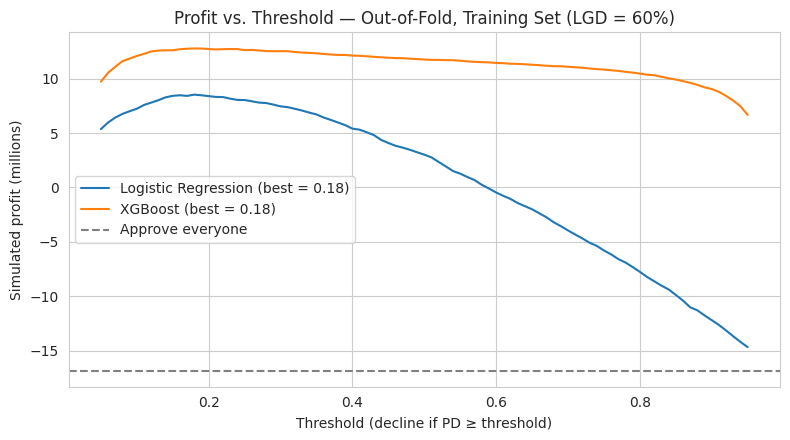

Sensitivity of the best threshold to the LGD assumption:
  LGD 40%: Logistic Regression: 0.28 | XGBoost: 0.31
  LGD 60%: Logistic Regression: 0.18 | XGBoost: 0.18
  LGD 80%: Logistic Regression: 0.15 | XGBoost: 0.12


In [29]:
from sklearn.model_selection import cross_val_predict

LGD = 0.60
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

def portfolio_profit(y_true, pd_scores, threshold, amount, rate, lgd=LGD):
    approved = pd_scores < threshold
    y_true, amount, rate = np.asarray(y_true), np.asarray(amount), np.asarray(rate)
    gain = (amount * rate / 100)[approved & (y_true == 0)].sum()
    loss = (amount * lgd)[approved & (y_true == 1)].sum()
    return gain - loss

# Interest rate for the simulation: use the pipeline's imputed values where the raw rate is missing.
rate_train = lr_model.named_steps["prep"].named_transformers_["rate"].named_steps["impute"] \
                 .transform(X_train[RATE])["loan_int_rate"]

oof = {name: cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
       for name, m in [("Logistic Regression", lr_model), ("XGBoost", xgb_model)]}

best_threshold = {}
plt.figure(figsize=(8, 4.5))
for name, scores in oof.items():
    profits = [portfolio_profit(y_train, scores, t, X_train["loan_amnt"], rate_train) for t in thresholds]
    best_threshold[name] = thresholds[int(np.argmax(profits))]
    plt.plot(thresholds, np.array(profits) / 1e6, label=f"{name} (best = {best_threshold[name]:.2f})")
approve_all = portfolio_profit(y_train, np.zeros(len(y_train)), 1.0, X_train["loan_amnt"], rate_train)
plt.axhline(approve_all / 1e6, color="grey", linestyle="--", label="Approve everyone")
plt.xlabel("Threshold (decline if PD ≥ threshold)")
plt.ylabel("Simulated profit (millions)")
plt.title(f"Profit vs. Threshold — Out-of-Fold, Training Set (LGD = {LGD:.0%})")
plt.legend()
plt.tight_layout()
plt.show()

print("Sensitivity of the best threshold to the LGD assumption:")
for lgd in [0.4, 0.6, 0.8]:
    row = {name: thresholds[int(np.argmax([portfolio_profit(y_train, s, t, X_train["loan_amnt"], rate_train, lgd)
                                           for t in thresholds]))] for name, s in oof.items()}
    print(f"  LGD {lgd:.0%}: " + " | ".join(f"{k}: {v:.2f}" for k, v in row.items()))

**Reading the curve.** Very low thresholds decline almost everyone (little profit), very high thresholds approve almost everyone (many defaults). Under these assumptions, approving everyone loses money, and both models peak at a threshold of **0.18**: decline any applicant with a predicted PD of 18% or more. That is far below 0.5 because a default costs much more (60% of the loan) than a rejected good customer (one year of interest, typically 7–20%).

The shapes of the two curves also differ. Logistic Regression's profit falls quickly when the threshold moves away from its peak, while XGBoost's curve is almost flat between about 0.1 and 0.6. XGBoost separates defaulters from good payers so clearly that most applicants get scores near 0 or near 1, so the exact cut-off matters much less: a practical advantage, since the LGD assumption is uncertain.

The sensitivity check shows the decision is robust in direction but not in exact value: with a 40% LGD the best threshold rises to about 0.3, and with 80% it drops to 0.12–0.15. In a real lender, LGD would come from its own recovery data.

## 11. Final Evaluation on the Test Set

Both models, already fitted on the full training set with their chosen hyperparameters, are now scored on the test set for the first and only time.

Metrics:
- **ROC-AUC:** probability that a random defaulter gets a higher PD than a random good payer (0.5 = random, 1 = perfect).
- **Gini = 2·AUC − 1:** the same information on the scale banks usually report.
- **KS:** maximum separation between the score distributions of defaulters and good payers; another standard banking metric.
- **Brier score:** mean squared error of the probabilities (lower is better). Measures probability quality, not just ranking.
- **Recall / precision at the chosen threshold:** share of defaulters declined, and share of declined applicants who were actual defaulters.

In [30]:
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             recall_score, precision_score, confusion_matrix)

rate_test = lr_model.named_steps["prep"].named_transformers_["rate"].named_steps["impute"] \
                .transform(X_test[RATE])["loan_int_rate"]
test_scores = {"Logistic Regression": lr_model.predict_proba(X_test)[:, 1],
               "XGBoost": xgb_model.predict_proba(X_test)[:, 1]}

rows = {}
for name, p in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    t = best_threshold[name]
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows[name] = {
        "ROC-AUC": auc, "Gini": 2 * auc - 1, "KS": np.max(tpr - fpr),
        "Brier": brier_score_loss(y_test, p),
        "Threshold": t,
        "Recall": recall_score(y_test, pred), "Precision": precision_score(y_test, pred),
        "Recall @0.5": recall_score(y_test, (p >= 0.5).astype(int)),
        "Precision @0.5": precision_score(y_test, (p >= 0.5).astype(int)),
        "Approval rate": (pred == 0).mean(),
        "Defaulters approved (FN)": fn, "Good payers declined (FP)": fp,
        "Profit (millions)": portfolio_profit(y_test, p, t, X_test["loan_amnt"], rate_test) / 1e6,
    }

results = pd.DataFrame(rows)
approve_all_test = portfolio_profit(y_test, np.zeros(len(y_test)), 1.0, X_test["loan_amnt"], rate_test) / 1e6
print(results.round(4).to_string())
print(f"\nBrier score of a no-skill model (always predicts the base rate): "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_train.mean())):.4f}")
print(f"Profit if everyone is approved: {approve_all_test:.2f} millions")
print(f"Actual defaulters in the test set: {int(y_test.sum()):,} of {len(y_test):,}")

                           Logistic Regression   XGBoost
ROC-AUC                                 0.8698    0.9532
Gini                                    0.7396    0.9065
KS                                      0.5883    0.7762
Brier                                   0.1069    0.0492
Threshold                               0.1800    0.1800
Recall                                  0.8293    0.8597
Precision                               0.4806    0.7183
Recall @0.5                             0.5219    0.7454
Precision @0.5                          0.7234    0.9697
Approval rate                           0.6225    0.7382
Defaulters approved (FN)              242.0000  199.0000
Good payers declined (FP)            1271.0000  478.0000
Profit (millions)                       2.1324    3.3405

Brier score of a no-skill model (always predicts the base rate): 0.1709
Profit if everyone is approved: -4.32 millions
Actual defaulters in the test set: 1,418 of 6,482


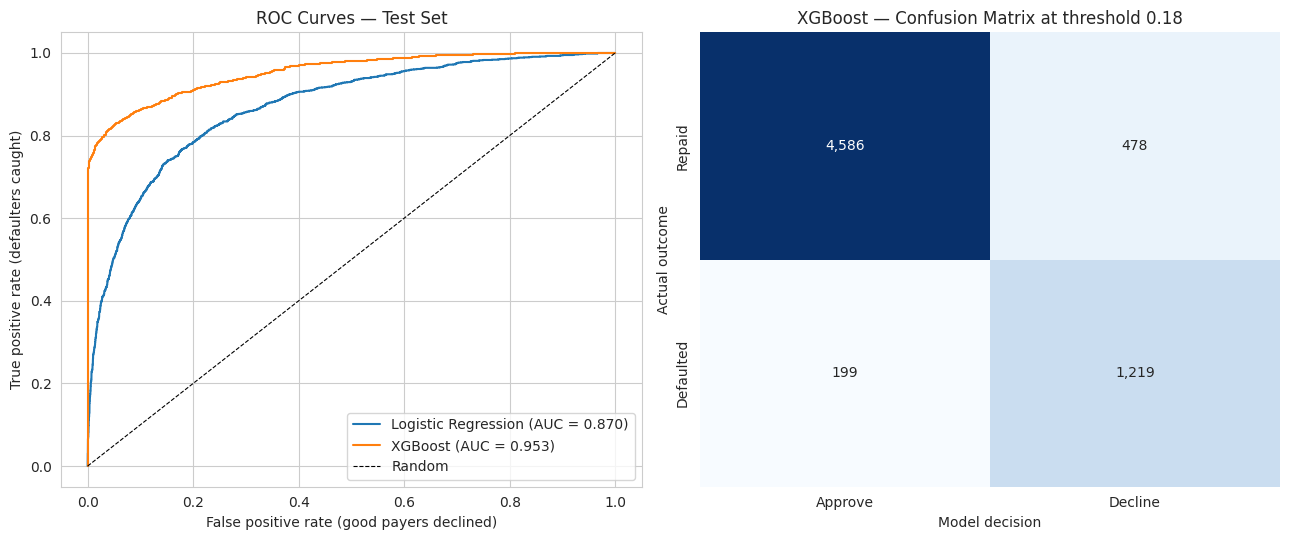

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, p in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
axes[0].set_xlabel("False positive rate (good payers declined)")
axes[0].set_ylabel("True positive rate (defaulters caught)")
axes[0].set_title("ROC Curves — Test Set")
axes[0].legend()

name = "XGBoost"
cm = confusion_matrix(y_test, (test_scores[name] >= best_threshold[name]).astype(int))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Approve", "Decline"], yticklabels=["Repaid", "Defaulted"])
axes[1].set_xlabel("Model decision")
axes[1].set_ylabel("Actual outcome")
axes[1].set_title(f"{name} — Confusion Matrix at threshold {best_threshold[name]:.2f}")
plt.tight_layout()
plt.show()

**Reading the test results.**

- **Ranking:** test AUCs (0.870 and 0.953) are practically identical to the cross-validation estimates, which confirms that the CV numbers were reliable and that nothing was tuned on the test set. A Gini of 0.91 is very high; real-world PD models usually score lower, which reflects how clean and educational this dataset is.
- **Decisions at threshold 0.18:** out of 1,418 defaulters in the test set, XGBoost approves 199 and Logistic Regression 242. Among 5,064 good payers, XGBoost wrongly declines 478 and Logistic Regression 1,271. Logistic Regression has to decline many more good customers to reach a similar recall, so its precision is only 48% vs 72%.
- **Money:** simulated profit is 3.34M with XGBoost and 2.13M with Logistic Regression, compared with a 4.32M loss if every applicant were approved.
- **Effect of the threshold:** at the default 0.5, XGBoost would catch only 75% of defaulters (Recall @0.5); the profit-based threshold raises that to 86%.

### 11.1 Calibration: Can the Probabilities Be Trusted?

A calibration curve groups applicants by predicted PD and compares it with the default rate actually observed in each group. A perfectly calibrated model lies on the diagonal: among applicants with PD ≈ 20%, about 20% default.

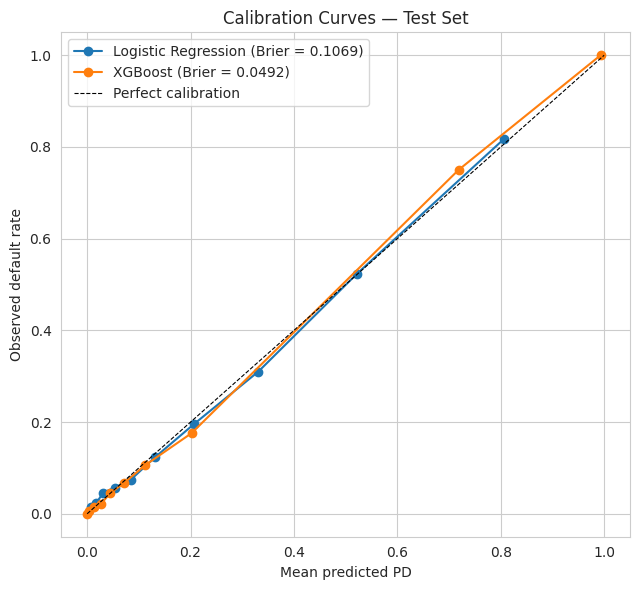

Logistic Regression: mean predicted PD 0.2192 vs observed default rate 0.2188
XGBoost: mean predicted PD 0.2189 vs observed default rate 0.2188


In [32]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(6.5, 6))
for name, p in test_scores.items():
    obs, pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(pred, obs, marker="o", label=f"{name} (Brier = {brier_score_loss(y_test, p):.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

for name, p in test_scores.items():
    print(f"{name}: mean predicted PD {p.mean():.4f} vs observed default rate {y_test.mean():.4f}")

**Reading the calibration.** Both curves follow the diagonal closely, and the average predicted PD (0.219) matches the observed default rate (0.219) for both models. XGBoost's small deviations in the middle bins (for example, applicants predicted around 20% default at about 18%) are minor. Because the classes were not artificially rebalanced, the predicted probabilities can be used directly as PDs, for example in an expected-loss calculation (PD × LGD × exposure). XGBoost's much lower Brier score (0.049 vs 0.107; 0.171 for a model with no skill) reflects both better ranking and good calibration.

## 12. Interpretability

A credit model has to be explainable: to the risk team, to regulators, and to applicants who are declined.

### 12.1 Logistic Regression Coefficients

Each coefficient is the change in log-odds of default when the feature increases by one standard deviation, holding the others constant. Dummy coefficients are relative to the reference category (`MORTGAGE` for home ownership, `DEBTCONSOLIDATION` for loan intent).

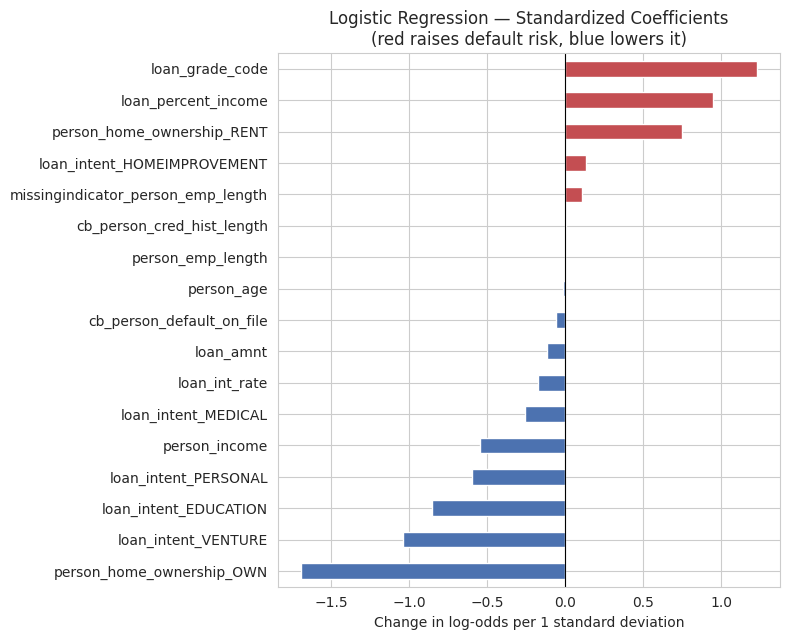

person_home_ownership_OWN            -1.697
loan_grade_code                       1.229
loan_intent_VENTURE                  -1.040
loan_percent_income                   0.948
loan_intent_EDUCATION                -0.854
person_home_ownership_RENT            0.745
loan_intent_PERSONAL                 -0.599
person_income                        -0.545
loan_intent_MEDICAL                  -0.261
loan_int_rate                        -0.178
loan_intent_HOMEIMPROVEMENT           0.133
loan_amnt                            -0.115
missingindicator_person_emp_length    0.105
cb_person_default_on_file            -0.061
person_age                           -0.015
cb_person_cred_hist_length            0.005
person_emp_length                    -0.002


In [33]:
coefs = pd.Series(lr_model.named_steps["model"].coef_[0],
                  index=lr_model.named_steps["prep"].get_feature_names_out()).sort_values()
plt.figure(figsize=(8, 6.5))
coefs.plot.barh(color=["#C44E52" if c > 0 else "#4C72B0" for c in coefs])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Standardized Coefficients\n(red raises default risk, blue lowers it)")
plt.xlabel("Change in log-odds per 1 standard deviation")
plt.tight_layout()
plt.show()
print(coefs.sort_values(key=abs, ascending=False).round(3).to_string())

**Reading the coefficients.**

- **Home ownership** (reference: `MORTGAGE`): `OWN` is strongly negative (−1.70) and `RENT` positive (+0.75). The order OWN < MORTGAGE < RENT is exactly the order of default rates seen in 7.3.
- **Loan purpose** (reference: `DEBTCONSOLIDATION`): venture, education and personal loans are less risky than debt consolidation. Home-improvement loans come out slightly riskier once the other factors are held constant, even though their raw default rate in 7.3 is a bit lower: another reminder that coefficients describe conditional effects.
- **Affordability and grade:** a larger loan relative to income (+0.95) and a worse grade (+1.23) raise risk; higher income lowers it (−0.55).
- **Two coefficients look wrong, and that is an important lesson.** `loan_int_rate` is slightly negative (−0.18) and `cb_person_default_on_file` is about zero, even though 7.4 and 7.5 showed that both are strongly associated with default. This is the multicollinearity warned about in 8.1: the grade already contains the information in the rate and in the previous-default flag (7.5). A linear coefficient measures the effect of a feature *holding all the others constant*; once the grade is known, the rate and the previous default add almost nothing, so their coefficients shrink to near zero or slightly below. Predictions are unaffected, but these two coefficients should not be read as "higher rates reduce risk". Section 9.1 confirms this: in a model without grade and rate, the previous-default coefficient becomes clearly positive.

### 12.2 SHAP Values for XGBoost

XGBoost has no coefficients. **SHAP** fills that gap: for every applicant, it splits the model's score into one contribution per feature, so that *base value + sum of contributions = the applicant's score*. The base value is the average score; a positive contribution pushes the applicant towards default, a negative one away from it. Values are in log-odds, the same scale as the Logistic Regression coefficients.

In [34]:
import shap

xgb_prep = xgb_model.named_steps["prep"]
X_test_xgb = xgb_prep.transform(X_test)
explainer = shap.TreeExplainer(xgb_model.named_steps["model"])
shap_values = explainer(X_test_xgb)
print("SHAP values:", shap_values.values.shape, "| base value (log-odds):", round(float(shap_values.base_values[0]), 3))

SHAP values: (6482, 19) | base value (log-odds): -1.32


### 12.3 SHAP — Global View

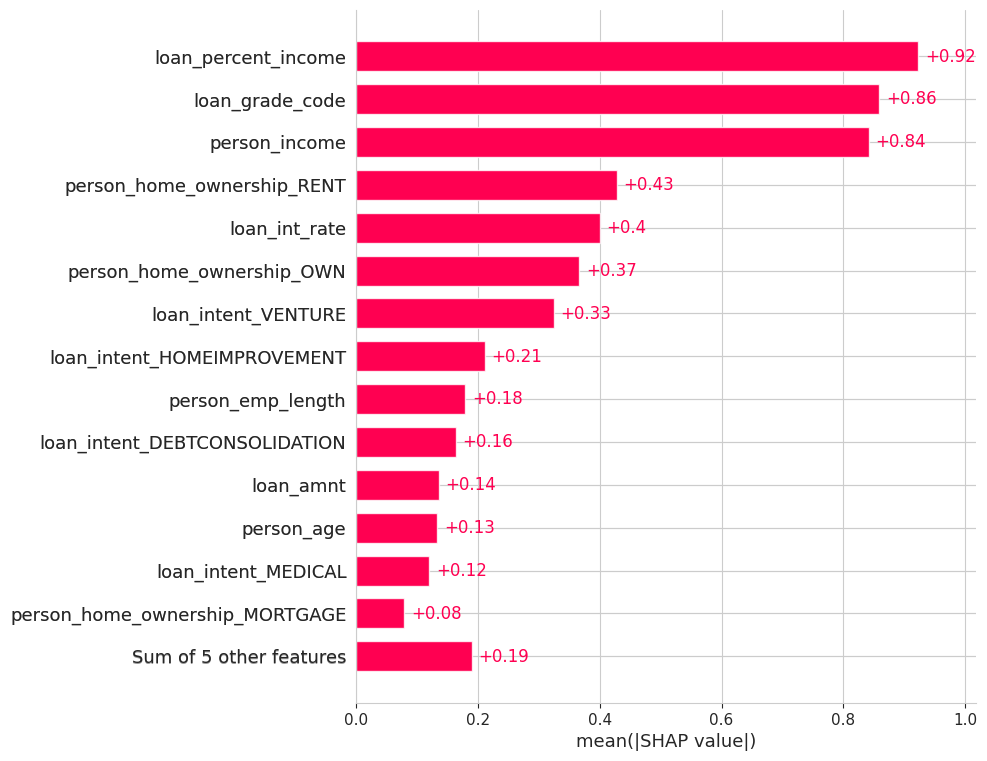

In [35]:
shap.plots.bar(shap_values, max_display=15)

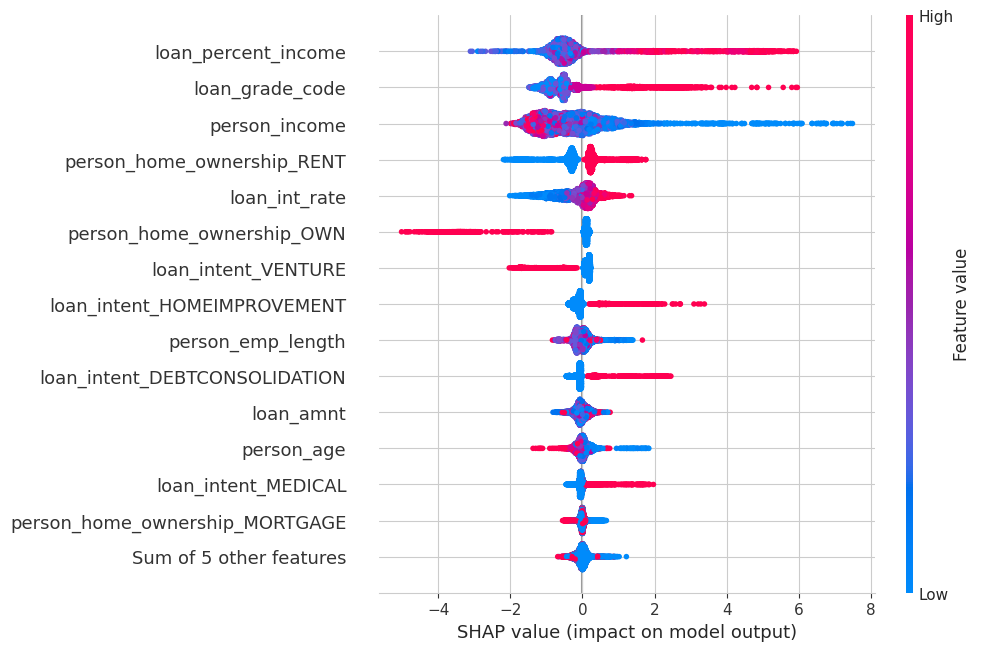

In [36]:
shap.plots.beeswarm(shap_values, max_display=15)

**Reading the global view.** The three most influential features are `loan_percent_income`, `loan_grade_code` and `person_income`, followed by home ownership, interest rate and loan purpose. The beeswarm confirms the expected directions: a higher loan-to-income ratio, a worse grade, a higher rate and renting push risk up (red dots on the right), while higher income and owning a home push it down.

Two contrasts with Logistic Regression are worth noting. Here `loan_int_rate` pushes risk up, in the intuitive direction, because trees do not have to divide one linear weight among correlated features. And `cb_person_default_on_file` ranks near the bottom, which again reflects that the grade already contains that information (7.5).

### 12.4 SHAP — Non-Linear Effects

A dependence plot shows how one feature's contribution changes across its range. A straight line would mean a linear effect, which is what Logistic Regression assumes; bends and steps are what XGBoost captures in addition.

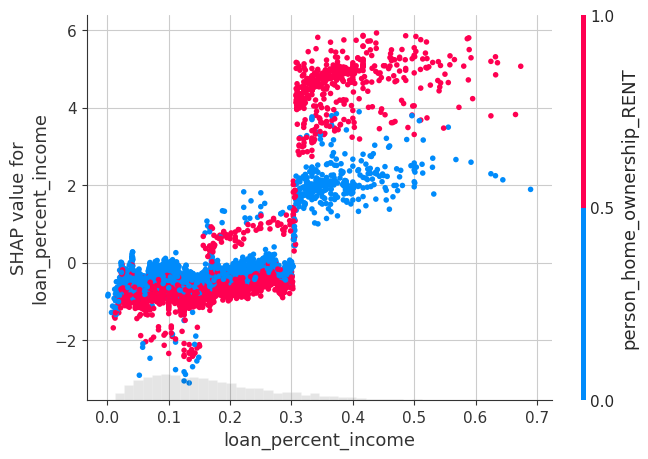

In [37]:
shap.plots.scatter(shap_values[:, "loan_percent_income"], color=shap_values)

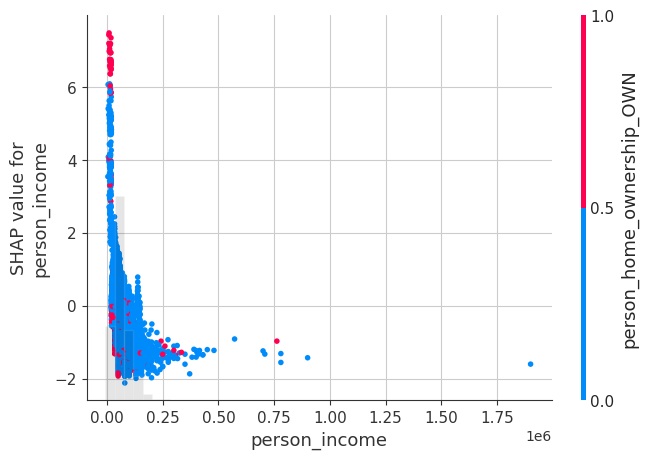

In [38]:
shap.plots.scatter(shap_values[:, "person_income"], color=shap_values)

**Reading the dependence plots.**

- **`loan_percent_income` shows a step, not a slope.** Below about 30% of income, the contribution is flat and slightly protective. Between 30% and 35% it jumps by roughly +3 log-odds and keeps rising after that. This threshold effect is the main reason XGBoost outperforms Logistic Regression: one straight line cannot reproduce a step. Whether the step reflects a real affordability limit or the way this educational dataset was generated cannot be determined from the data.
- **`person_income`** lowers risk as it rises, but mostly at the low end: incomes below about 28,000 add around +1.5 log-odds, while the effect flattens above about 115,000. This diminishing effect is what the log transformation approximates for Logistic Regression.

### 12.5 SHAP — Explaining Individual Decisions

A waterfall plot starts at the base value and adds each feature's contribution until it reaches one applicant's score. This is the explanation a credit analyst could give for a specific decision.

Highest-risk applicant: PD = 1.000 | actual outcome = 1


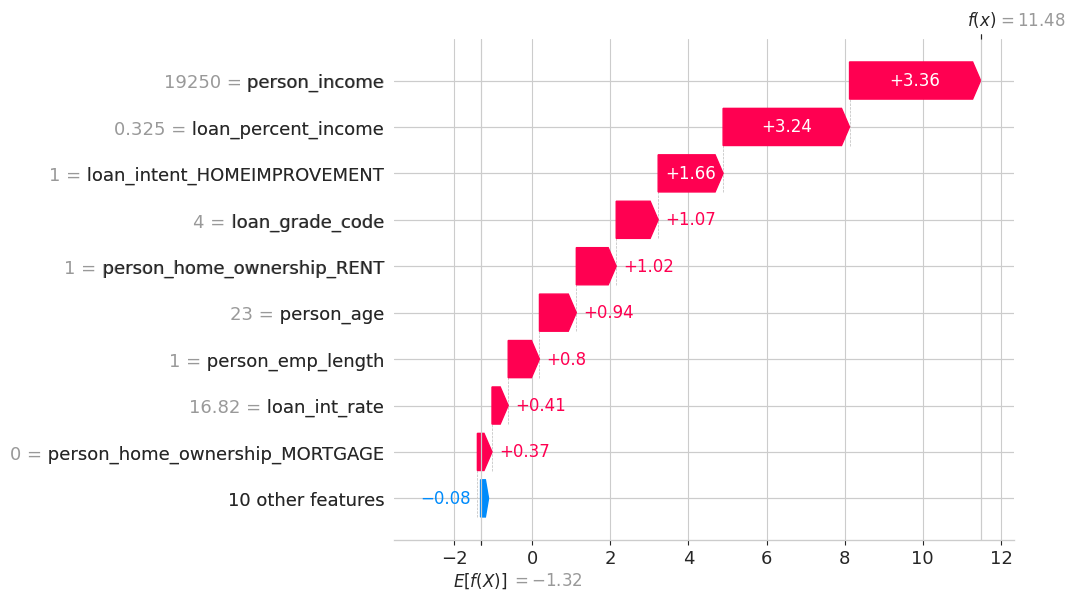

In [39]:
p_xgb = test_scores["XGBoost"]
i_high, i_low = int(np.argmax(p_xgb)), int(np.argmin(p_xgb))
print(f"Highest-risk applicant: PD = {p_xgb[i_high]:.3f} | actual outcome = {y_test.iloc[i_high]}")
shap.plots.waterfall(shap_values[i_high], max_display=10)

Lowest-risk applicant: PD = 0.0000 | actual outcome = 0


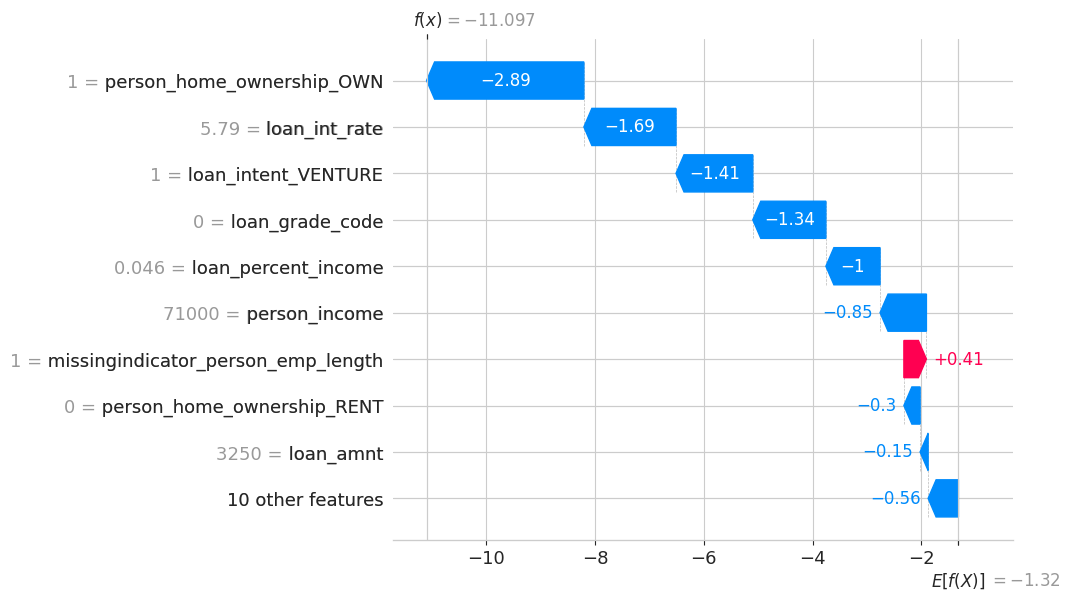

In [40]:
print(f"Lowest-risk applicant: PD = {p_xgb[i_low]:.4f} | actual outcome = {y_test.iloc[i_low]}")
shap.plots.waterfall(shap_values[i_low], max_display=10)

**Reading the two cases.**

- **Highest risk (PD ≈ 1.00, actually defaulted):** low income (19,250), a loan equal to 32% of that income (just past the step seen above), grade E, a home-improvement purpose and renting. Each of these pushes the score up.
- **Lowest risk (PD ≈ 0.00, actually repaid):** owns their home, grade A at a 5.79% rate, a venture loan, and a loan of under 5% of income. Every major feature pushes the score down.

An explanation like this can be given to a declined applicant ("the main reasons were the size of the loan relative to your income and the loan grade"), which is what regulators expect from credit decisions.

## 13. Conclusions, Limitations and Next Steps

### Conclusions

1. **Data quality work mattered.** Removing 165 duplicates and 7 impossible rows, recomputing an inconsistent derived field, and treating missing values according to what they mean (missing employment length is a risk signal; missing interest rate is not) produced a clean base without discarding plausible extreme values.
2. **XGBoost is the better PD model for this portfolio.** It ranks risk much better (test Gini 0.91 vs 0.74), its probabilities are well calibrated, and it produces clearly better lending decisions: fewer approved defaulters and far fewer declined good customers.
3. **Most of its advantage comes from a non-linear affordability effect:** risk jumps once a loan passes about 30% of income.
4. **The decision threshold should come from business costs, not convention.** Under the stated assumptions, the best cut-off is 0.18, not 0.5.
5. **Logistic Regression remains useful as a transparent benchmark**, provided its coefficients are read with the multicollinearity caveat in mind.
6. **The models apply after the lender has graded and priced the loan.** Part of their performance comes from the lender's own grade and rate (Section 9.1). For pre-approval, a reduced XGBoost without those features still reaches a CV AUC of about 0.90.

### Limitations

- Educational dataset: results are cleaner than real-world data would allow.
- The full models depend on the lender's own grade and rate, so they are valid only for decisions taken after grading and pricing.
- No application dates: no out-of-time validation or monitoring of population drift.
- The profit simulation depends on assumed LGD and gain; no loan term, fees or funding costs are available.
- XGBoost fits the training data much more closely than it generalizes (train AUC 0.986 vs CV 0.947). The CV and test results show this is acceptable here, but it should be monitored.

### What Would Change in Production?

This notebook validates the model on a random split of a static dataset. A production PD model would add:

- **Out-of-time validation.** Train on older applications and validate on the most recent ones. A random split mixes periods and usually overstates performance, because future applicants may differ from past ones.
- **Drift monitoring.** Track the Population Stability Index (PSI) of the score and of key features between the development sample and new applications. A common rule of thumb: PSI below 0.1 is stable, 0.1–0.25 needs attention, above 0.25 calls for investigation.
- **Backtesting.** Once outcomes are known, compare predicted PDs with realized default rates by score band, and check that the ranking power (Gini) holds.
- **Recalibration and retraining.** Recalibrate when predicted and observed default rates drift apart, retrain when the ranking itself degrades, and review the decision policy whenever its economic inputs change.
- **Reject inference.** Outcomes are only observed for approved loans. A model trained only on past approvals learns from a filtered population, and this bias has to be addressed when the approval policy changes.
- **Governance.** Model documentation, independent validation and a champion–challenger setup, where a new model is tested on part of the traffic before replacing the current one.

### Next Steps

- Widen the XGBoost search: the best depth and learning rate were at the edge of the grid.
- Add a `loan_percent_income > 0.30` indicator to Logistic Regression to measure how much of the gap it closes; a simpler model with similar performance could be preferable for regulatory use.
- Add monotonic constraints in XGBoost (for example, risk may only rise with loan-to-income), a common requirement in regulated credit models.
- Check performance and approval rates across age groups for fairness.
- With real data: out-of-time validation, and LGD/exposure models to compute expected loss.
- Save the fitted pipeline with `joblib` so new applications can be scored with exactly the same preprocessing.